In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a cohesive dashboard style mimcking enterprise Business Intelligence
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

#Read our clear dataset file
df = pd.read_csv("dataset/ecommerce_behavior.csv")
print(f"🎉 Success! Data fully ingested into active memory.")
print(f"Dataset Dimensions: {df.shape[0]} rows and {df.shape[1]} columns.\n")


🎉 Success! Data fully ingested into active memory.
Dataset Dimensions: 17049 rows and 18 columns.



In [20]:
# Print out the dataset columns and their structural types
print("=== DATASET COLUMNS ===")
print(df.info())

print("============ TASK 2: EXPLORATORY DATA ANALYSIS ============\n")

print("--- 1. Structural Schema Overview ---")
print(df.info())
print("\n" + "="*50 + "\n")

print("--- 2. Auditing Missing/Null Values ---")
null_summary = df.isnull().sum()
print(null_summary[null_summary > 0] if null_summary.sum() > 0 else "No missing values detected across features!")
print("\n" + "="*50 + "\n")

print("--- 3. Identifying & Purging Duplicate Logs ---")
duplicate_count = df.duplicated().sum()
print(f"Duplicate records located: {duplicate_count}")
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("DataFrame successfully de-duplicated.")
print("\n" + "="*50 + "\n")

print("--- 4. Summary Statistics for Behavioral Columns ---")
print(df.describe())

=== DATASET COLUMNS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17049 entries, 0 to 17048
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  17049 non-null  object 
 1   Customer_ID               17049 non-null  object 
 2   Date                      17049 non-null  object 
 3   Age                       17049 non-null  int64  
 4   Gender                    17049 non-null  object 
 5   City                      17049 non-null  object 
 6   Product_Category          17049 non-null  object 
 7   Unit_Price                17049 non-null  float64
 8   Quantity                  17049 non-null  int64  
 9   Discount_Amount           17049 non-null  float64
 10  Total_Amount              17049 non-null  float64
 11  Payment_Method            17049 non-null  object 
 12  Device_Type               17049 non-null  object 
 13  Session_Duration_Minutes  17049 non-n


=== SAMPLE DATA ===
       Order_ID Customer_ID        Date  Age Gender    City Product_Category  \
0  ORD_000001-1  CUST_00001  2023-05-29   40   Male  Ankara            Books   
1  ORD_000001-2  CUST_00001  2023-10-12   40   Male  Ankara    Home & Garden   
2  ORD_000001-3  CUST_00001  2023-12-05   40   Male  Ankara           Sports   

   Unit_Price  Quantity  Discount_Amount  Total_Amount  Payment_Method  \
0       29.18         1             0.00         29.18  Digital Wallet   
1      644.40         1           138.05        506.35     Credit Card   
2      332.82         5             0.00       1664.10     Credit Card   

  Device_Type  Session_Duration_Minutes  Pages_Viewed  Is_Returning_Customer  \
0      Mobile                        14             9                   True   
1     Desktop                        14             8                   True   
2      Mobile                        15            10                   True   

   Delivery_Time_Days  Customer_Rating  

/tmp/ipykernel_1571/1410337383.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x=cat_col, y=spend_col, data=category_perf, palette='Blues_r')


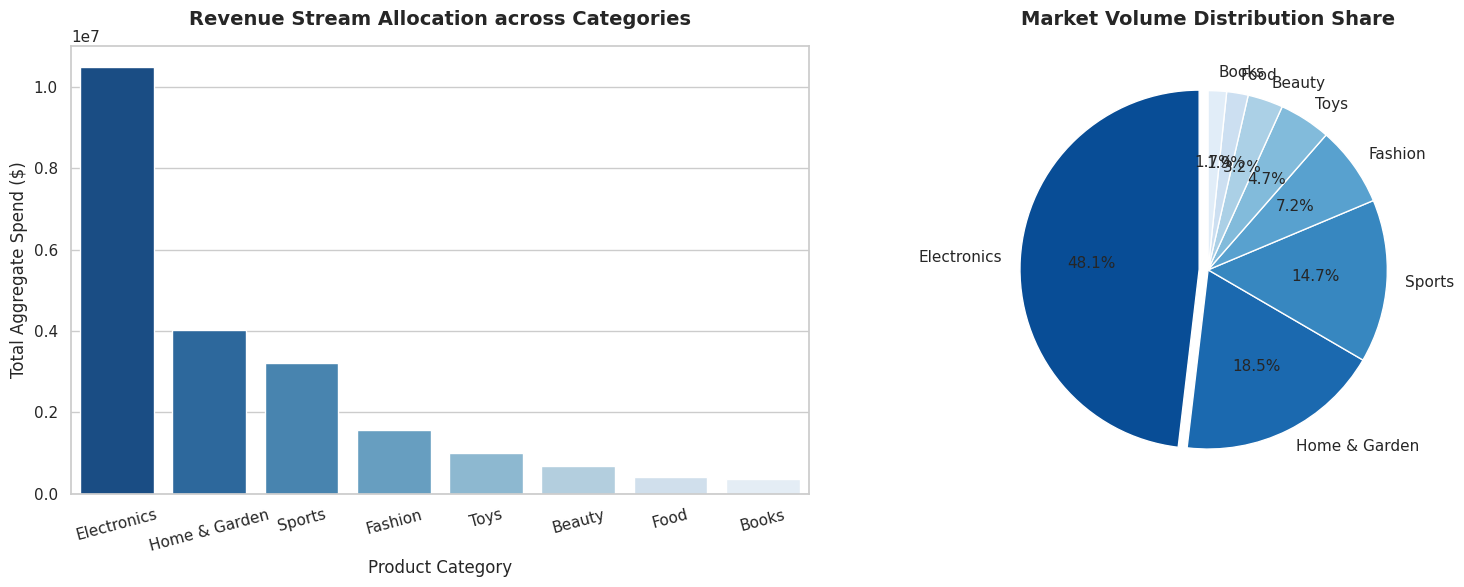

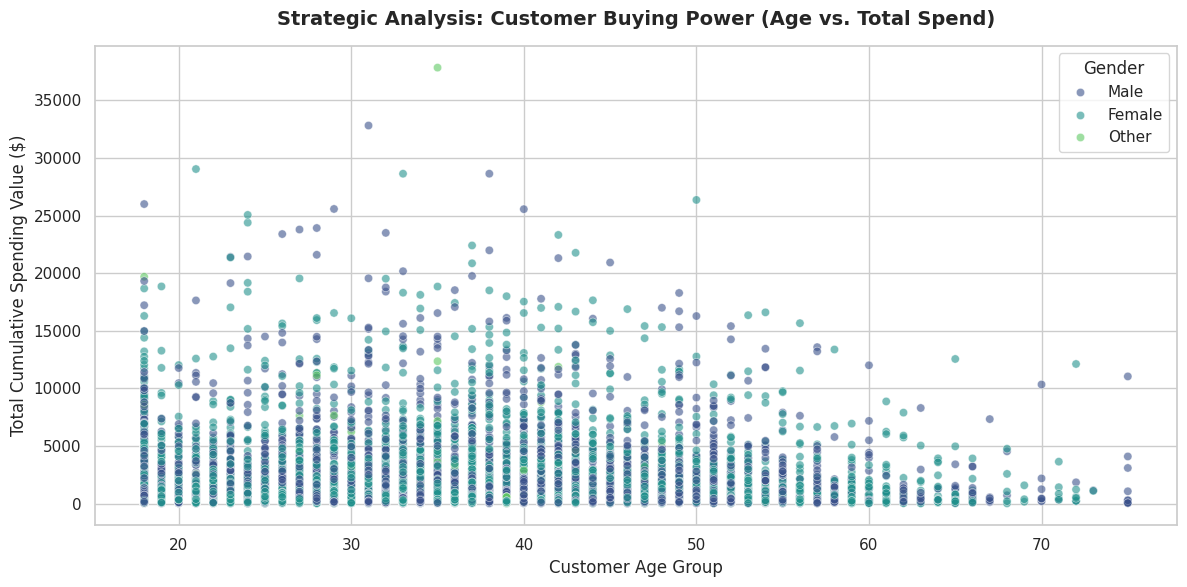

In [32]:
# Show a tiny sample of the data rows
print("\n=== SAMPLE DATA ===")
print(df.head(3))

print("============ TASK 3: EXECUTIVE DATA VISUALIZATION ============\n")

# 1. Map columns directly from your actual kaggel schema
cat_col = 'Product_Category'
spend_col = 'Total_Amount'
age_col = 'Age'
gender_col = 'Gender'

# Setup a clean dashboard plotting layout for Chart A and Chart B
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Chart A: Total Revenue Stream per Product Category (Bar Chart)
category_perf = df.groupby(cat_col)[spend_col].sum().sort_values(ascending=False).reset_index()
sns.barplot(ax=axes[0], x=cat_col, y=spend_col, data=category_perf, palette='Blues_r')
axes[0].set_title(f'Revenue Stream Allocation across Categories', weight='bold', pad=15)
axes[0].set_xlabel('Product Category')
axes[0].set_ylabel('Total Aggregate Spend ($)')
axes[0].tick_params(axis='x', rotation=15)

    # Chart B: Overall Volume Contribution Share (Pie Chart)
axes[1].pie(category_perf[spend_col], labels=category_perf[cat_col], autopct='%1.1f%%',
                startangle=90, colors=sns.color_palette('Blues_r', len(category_perf)),
                explode=[0.05] + [0]*(len(category_perf)-1))
axes[1].set_title('Market Volume Distribution Share', weight='bold', pad=15)

plt.tight_layout()
plt.show()
#--- Horizontal separator---
print("\n" + "="*80 + "\n")

# Chart C: Behavioral Deep-Dive - Customer Age vs Total Spend Colored by Gender
plt.figure(figsize=(12, 6))
sns.scatterplot(x=age_col, y=spend_col, data=df, hue=gender_col, alpha=0.6, palette='viridis')
plt.title(f'Strategic Analysis: Customer Buying Power (Age vs. Total Spend)', weight='bold', pad=15)
plt.xlabel('Customer Age Group')
plt.ylabel('Total Cumulative Spending Value ($)')
plt.tight_layout()
plt.show()